In [279]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 3)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.boston_housing.load_data()
EPOCHS = 100

In [280]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

In [286]:
model = Sequential()
model.add(Dense(16, activation = 'relu', kernel_regularizer='l2'))
# model.add(BatchNormalization())
model.add(Dense(8, activation = 'relu', kernel_regularizer='l2'))
# model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))

In [287]:
model.compile(loss = "mae", optimizer = 'adam', metrics=["mse"])

In [288]:
history=  model.fit(x_train, y_train, batch_size = 8, epochs = EPOCHS, validation_data = (x_test, y_test) , callbacks = [es])

Epoch 1/100
51/51 [==============================] - 0s 3ms/step - loss: 21.8358 - mse: 850.3148 - val_loss: 7.8531 - val_mse: 97.7070
Epoch 2/100
51/51 [==============================] - 0s 1ms/step - loss: 8.9615 - mse: 134.5333 - val_loss: 6.3599 - val_mse: 61.1750
Epoch 3/100
51/51 [==============================] - 0s 1ms/step - loss: 8.0104 - mse: 105.2408 - val_loss: 6.1335 - val_mse: 63.8265
Epoch 4/100
51/51 [==============================] - 0s 1ms/step - loss: 7.2891 - mse: 91.4193 - val_loss: 6.3972 - val_mse: 70.7720
Epoch 5/100
51/51 [==============================] - 0s 1ms/step - loss: 7.1433 - mse: 83.2895 - val_loss: 5.8906 - val_mse: 57.4910
Epoch 6/100
51/51 [==============================] - 0s 1ms/step - loss: 6.5355 - mse: 76.1577 - val_loss: 5.7642 - val_mse: 58.3673
Epoch 7/100
51/51 [==============================] - 0s 1000us/step - loss: 6.2783 - mse: 74.5968 - val_loss: 6.0615 - val_mse: 66.2089
Epoch 8/100
51/51 [==============================] - 0s 1000us

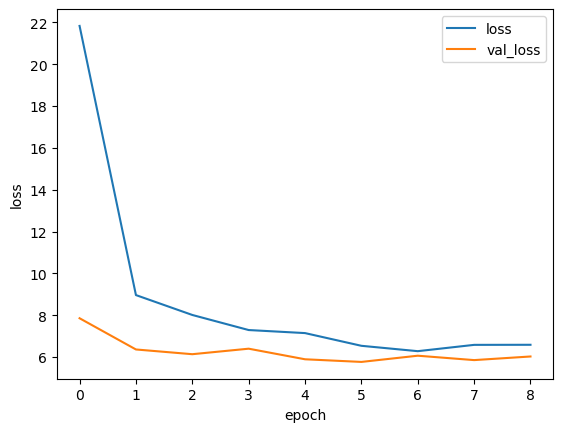

In [289]:
hist = pd.DataFrame(history.history)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [285]:
print(model.predict(x_test[11].reshape(1, -1))[0,0])
print(y_test[11])

14.857537
14.5
